# Figure S5 — Class-label-shuffle stability analysis

The best data-driven model (griffin_diff + SVM + all retained TSSs, healthy
vs BRCA+CRC) refit under 10 random class-label permutations:
(a) mean 10-fold CV AUROC per permutation collapses to chance, far below the
observed value; (b) Pearson correlation between each permuted model's weights
and the true model's weights is near zero; (c) the top-1000 TSSs by weight
barely overlap the true model's top-1000 (Jaccard).

**Source data**: `data/figS5_label_shuffle.csv` (one row per permutation) and
`data/figS5_config.csv` (true-model reference), written by
`export/export_figS5.py` from the label-shuffle experiment
(`slurm/label_shuffle.sh`, `model_hpc.py --run_label_shuffle_experiment`).
No pickles, no cluster paths, no network. Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shuffles = pd.read_csv("data/figS5_label_shuffle.csv")
config = pd.read_csv("data/figS5_config.csv")
display(config)
observed_cv_auc = float(config["observed_cv_auc"].iloc[0])
print(f"{len(shuffles)} permutations; observed CV AUC = {observed_cv_auc:.4f}")

,observed_cv_auc,true_full_auc,n_shuffles,top_k,weights_type,feature,classifier,n_genes,selection_type,source_dir
0,0.959524,1.0,10,1000,coefficients,griffin_diff,Support Vector Machine,15000,mean_diff,nested_cv_results_cris/label_shuffle_best_mode...


10 permutations; observed CV AUC = 0.9595


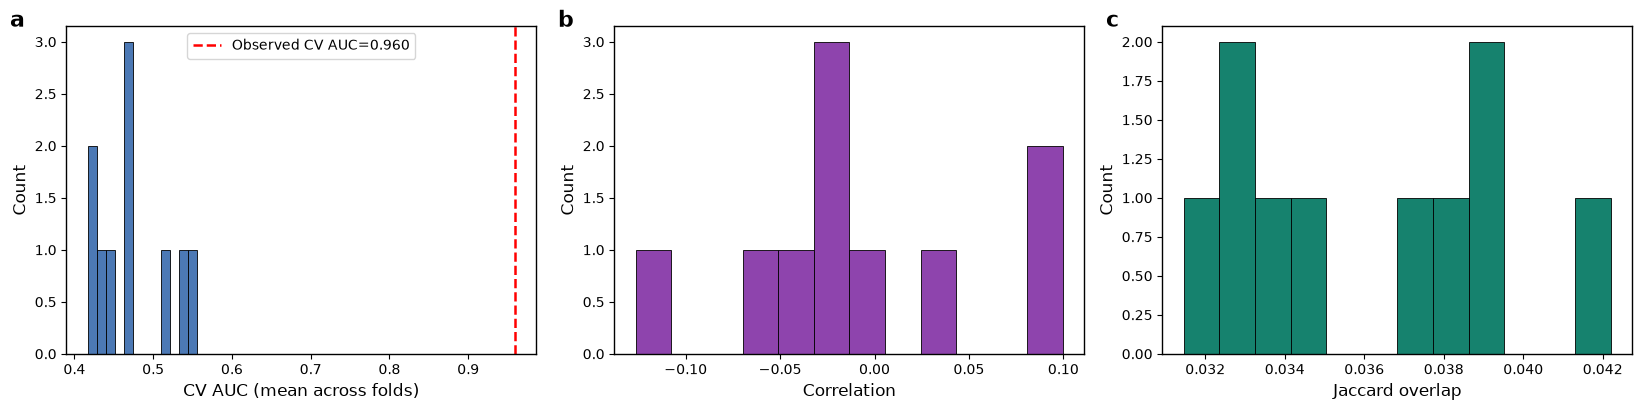

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.2))

# ── Panel a: shuffled CV AUC vs observed ──
ax = axes[0]
ax.hist(shuffles["cv_auc_mean"], bins=12, color="#4C79B5", edgecolor="black", linewidth=0.6)
ax.axvline(observed_cv_auc, color="red", linestyle="--", linewidth=1.8,
           label=f"Observed CV AUC={observed_cv_auc:.3f}")
ax.set_xlabel("CV AUC (mean across folds)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.legend(fontsize=10, loc="upper center")

# ── Panel b: weight correlation with the true model ──
ax = axes[1]
ax.hist(shuffles["weight_correlation_with_true"], bins=12, color="#8E44AD",
        edgecolor="black", linewidth=0.6)
ax.set_xlabel("Correlation", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# ── Panel c: Jaccard overlap of top-K TSSs ──
ax = axes[2]
ax.hist(shuffles["top_k_jaccard_with_true"], bins=12, color="#16826E",
        edgecolor="black", linewidth=0.6)
ax.set_xlabel("Jaccard overlap", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for ax, letter in zip(axes, "abc"):
    ax.text(-0.12, 1.05, letter, transform=ax.transAxes,
            fontsize=16, fontweight="bold", va="top")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")
    ax.tick_params(labelsize=10)

plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/figS5.png", dpi=300, bbox_inches="tight")
fig.savefig("output/figS5.pdf", bbox_inches="tight")
plt.show()

## Checks against the manuscript

S5 caption: performance collapses under permutation; weight correlations show
almost no relation to the true model; top-1000 overlap is minimal
(Jaccard ≈ 0.032–0.042).

In [3]:
print(f"observed CV AUC:        {observed_cv_auc:.4f}   (manuscript: 0.960)")
print(f"shuffled CV AUC:        {shuffles['cv_auc_mean'].mean():.3f} ± "
      f"{shuffles['cv_auc_mean'].std(ddof=1):.3f} "
      f"(range {shuffles['cv_auc_mean'].min():.3f}–{shuffles['cv_auc_mean'].max():.3f})")
print(f"weight correlation:     range {shuffles['weight_correlation_with_true'].min():+.3f} "
      f"to {shuffles['weight_correlation_with_true'].max():+.3f}")
print(f"top-K Jaccard overlap:  range {shuffles['top_k_jaccard_with_true'].min():.3f} "
      f"to {shuffles['top_k_jaccard_with_true'].max():.3f}   (manuscript: ~0.032–0.042)")
assert shuffles["cv_auc_mean"].max() < observed_cv_auc - 0.3, \
    "expected all shuffled AUCs far below the observed AUC"

observed CV AUC:        0.9595   (manuscript: 0.960)
shuffled CV AUC:        0.472 ± 0.048 (range 0.417–0.556)
weight correlation:     range -0.126 to +0.100
top-K Jaccard overlap:  range 0.031 to 0.042   (manuscript: ~0.032–0.042)
